In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

with open('../models/churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

X_test = pd.read_csv('../data/X_processed.csv').iloc[int(7043*0.8):]
y_test = pd.read_csv('../data/y_processed.csv').squeeze().iloc[int(7043*0.8):]

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.3).astype(int)

print("Test set size:", len(X_test))
print("Predicted churners:", preds.sum())
print("Actual churners:", y_test.sum())

Test set size: 1409
Predicted churners: 506
Actual churners: 381


In [2]:
# Business assumptions - these are industry standard telecom numbers
TOTAL_CUSTOMERS = 7043
AVG_CUSTOMER_LIFETIME_VALUE = 1800  # Average revenue per customer per year
RETENTION_CAMPAIGN_COST = 50        # Cost per customer contacted (offer, staff, etc.)
RETENTION_SUCCESS_RATE = 0.30       # 30% of contacted at-risk customers stay

# Model performance at threshold 0.3
MODEL_RECALL = 0.7674        # We catch 76.74% of churners
MODEL_PRECISION = 0.5266     # 52.66% of our alerts are real churners

# Actual churn numbers
ANNUAL_CHURN_RATE = 0.2654
ANNUAL_CHURNERS = int(TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE)

print(f"Total customers:          {TOTAL_CUSTOMERS:,}")
print(f"Annual churn rate:        {ANNUAL_CHURN_RATE*100:.1f}%")
print(f"Annual churners:          {ANNUAL_CHURNERS:,}")
print(f"Customer lifetime value:  ${AVG_CUSTOMER_LIFETIME_VALUE:,}")
print(f"Retention campaign cost:  ${RETENTION_CAMPAIGN_COST}/customer")
print(f"Retention success rate:   {RETENTION_SUCCESS_RATE*100:.0f}%")

Total customers:          7,043
Annual churn rate:        26.5%
Annual churners:          1,869
Customer lifetime value:  $1,800
Retention campaign cost:  $50/customer
Retention success rate:   30%


In [3]:
# What happens if we do nothing - no model, no retention campaign
revenue_lost_without_model = ANNUAL_CHURNERS * AVG_CUSTOMER_LIFETIME_VALUE

print("SCENARIO 1: NO MODEL (Current State)")
print(f"Customers lost annually:  {ANNUAL_CHURNERS:,}")
print(f"Revenue lost annually:    ${revenue_lost_without_model:,.0f}")
print(f"Monthly revenue loss:     ${revenue_lost_without_model/12:,.0f}")

SCENARIO 1: NO MODEL (Current State)
Customers lost annually:  1,869
Revenue lost annually:    $3,364,200
Monthly revenue loss:     $280,350


In [4]:
# What our model enables
customers_identified = int(ANNUAL_CHURNERS * MODEL_RECALL)
customers_saved = int(customers_identified * RETENTION_SUCCESS_RATE)

# Revenue impact
revenue_saved = customers_saved * AVG_CUSTOMER_LIFETIME_VALUE

# Campaign cost - we contact everyone we flagged, not just true churners
total_customers_contacted = int(customers_identified / MODEL_PRECISION)
campaign_cost = total_customers_contacted * RETENTION_CAMPAIGN_COST

# Net benefit
net_benefit = revenue_saved - campaign_cost
roi = (net_benefit / campaign_cost) * 100

print("SCENARIO 2: WITH MODEL")
print(f"Churners identified:        {customers_identified:,} of {ANNUAL_CHURNERS:,}")
print(f"Customers saved:            {customers_saved:,}")
print(f"Revenue saved:              ${revenue_saved:,.0f}")
print(f"\nCustomers contacted:        {total_customers_contacted:,}")
print(f"Campaign cost:              ${campaign_cost:,.0f}")
print(f"\nNet benefit:                ${net_benefit:,.0f}")
print(f"ROI:                        {roi:.0f}%")
print(f"Revenue protected:          {(customers_saved/ANNUAL_CHURNERS)*100:.1f}% of at-risk revenue")

SCENARIO 2: WITH MODEL
Churners identified:        1,434 of 1,869
Customers saved:            430
Revenue saved:              $774,000

Customers contacted:        2,723
Campaign cost:              $136,150

Net benefit:                $637,850
ROI:                        468%
Revenue protected:          23.0% of at-risk revenue


In [6]:
# What if retention success rate changes?
retention_rates = [0.10, 0.20, 0.30, 0.40, 0.50]

print("SENSITIVITY ANALYSIS - Retention Success Rate Impact")
print(f"{'Retention Rate':>15} {'Customers Saved':>16} {'Revenue Saved':>14} {'ROI':>8}")

results = []
for rate in retention_rates:
    saved = int(customers_identified * rate)
    rev_saved = saved * AVG_CUSTOMER_LIFETIME_VALUE
    net = rev_saved - campaign_cost
    r = (net / campaign_cost) * 100
    results.append({
        'retention_rate': rate,
        'customers_saved': saved,
        'revenue_saved': rev_saved,
        'roi': r
    })
    print(f"{rate*100:>14.0f}% {saved:>16,} ${rev_saved:>13,.0f} {r:>7.0f}%")

results_df = pd.DataFrame(results)

SENSITIVITY ANALYSIS - Retention Success Rate Impact
 Retention Rate  Customers Saved  Revenue Saved      ROI
            10%              143 $      257,400      89%
            20%              286 $      514,800     278%
            30%              430 $      774,000     468%
            40%              573 $    1,031,400     658%
            50%              717 $    1,290,600     848%


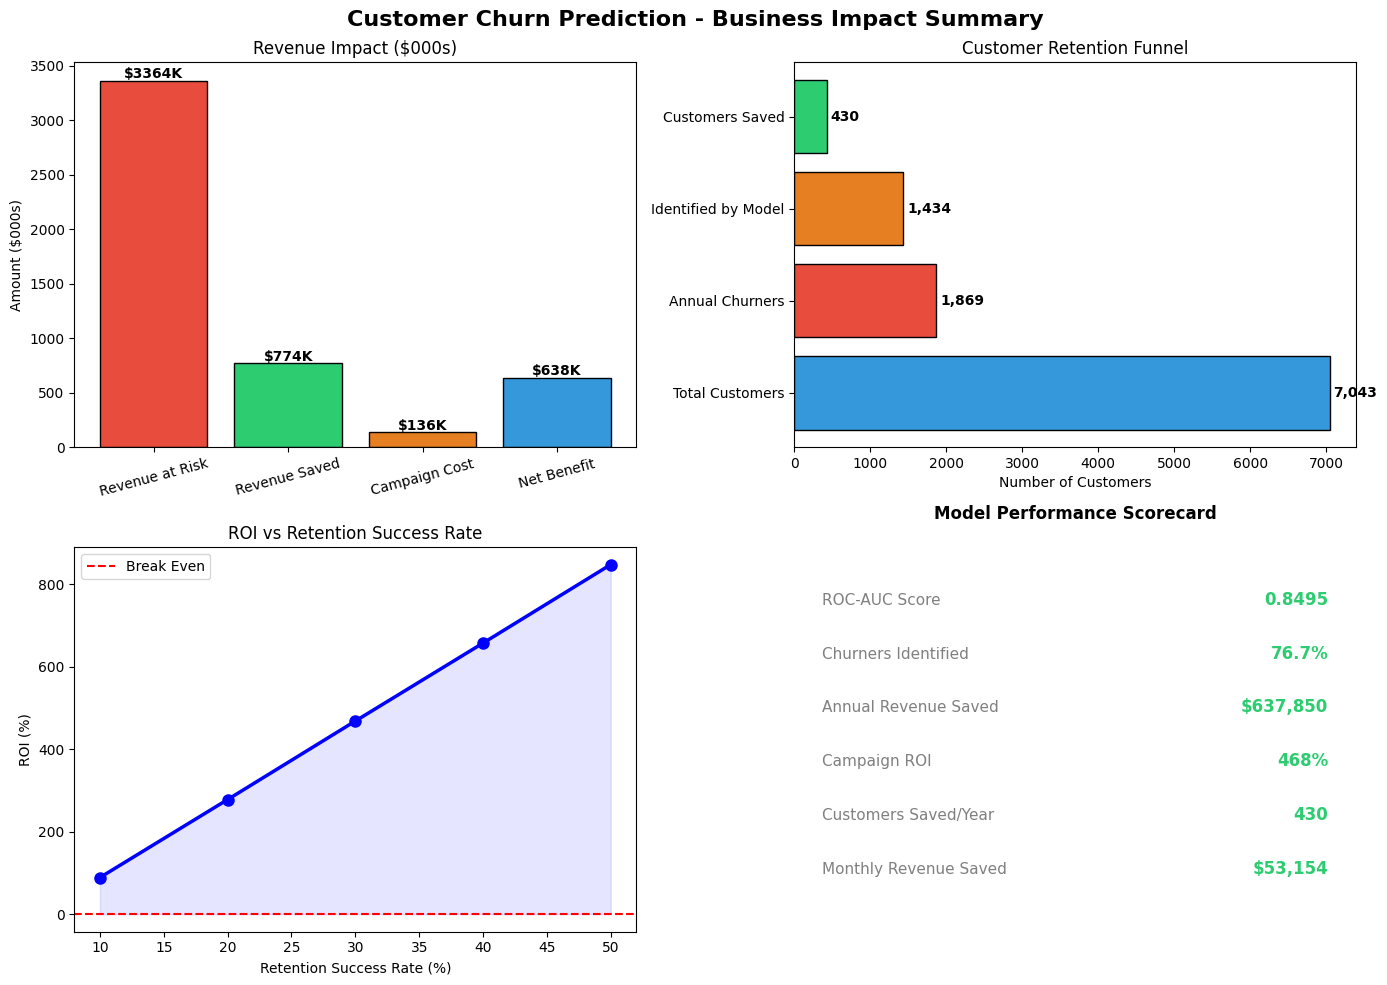

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Churn Prediction - Business Impact Summary', 
             fontsize=16, fontweight='bold')

# Chart 1 - Revenue comparison
categories = ['Revenue at Risk', 'Revenue Saved', 'Campaign Cost', 'Net Benefit']
values = [revenue_lost_without_model, revenue_saved, campaign_cost, net_benefit]
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

axes[0,0].bar(categories, [v/1000 for v in values], color=colors, edgecolor='black')
axes[0,0].set_title('Revenue Impact ($000s)')
axes[0,0].set_ylabel('Amount ($000s)')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(values):
    axes[0,0].text(i, v/1000 + 20, f'${v/1000:.0f}K', 
                   ha='center', fontweight='bold')

# Chart 2 - Customers funnel
funnel_labels = ['Total Customers', 'Annual Churners', 
                 'Identified by Model', 'Customers Saved']
funnel_values = [TOTAL_CUSTOMERS, ANNUAL_CHURNERS, 
                 customers_identified, customers_saved]
colors2 = ['#3498db', '#e74c3c', '#e67e22', '#2ecc71']

axes[0,1].barh(funnel_labels, funnel_values, color=colors2, edgecolor='black')
axes[0,1].set_title('Customer Retention Funnel')
axes[0,1].set_xlabel('Number of Customers')
for i, v in enumerate(funnel_values):
    axes[0,1].text(v + 50, i, str(f'{v:,}'), va='center', fontweight='bold')

# Chart 3 - ROI sensitivity
axes[1,0].plot(results_df['retention_rate']*100, results_df['roi'], 
               marker='o', linewidth=2.5, color='blue', markersize=8)
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break Even')
axes[1,0].fill_between(results_df['retention_rate']*100, 
                        results_df['roi'], 0, alpha=0.1, color='blue')
axes[1,0].set_title('ROI vs Retention Success Rate')
axes[1,0].set_xlabel('Retention Success Rate (%)')
axes[1,0].set_ylabel('ROI (%)')
axes[1,0].legend()

# Chart 4 - Key metrics scorecard
axes[1,1].axis('off')
metrics = [
    ('ROC-AUC Score',         '0.8495'),
    ('Churners Identified',   '76.7%'),
    ('Annual Revenue Saved',  '$637,850'),
    ('Campaign ROI',          '468%'),
    ('Customers Saved/Year',  '430'),
    ('Monthly Revenue Saved', '$53,154'),
]

axes[1,1].set_title('Model Performance Scorecard', fontweight='bold', pad=20)
for i, (metric, value) in enumerate(metrics):
    axes[1,1].text(0.05, 0.85 - i*0.14, metric, 
                   transform=axes[1,1].transAxes,
                   fontsize=11, color='gray')
    axes[1,1].text(0.95, 0.85 - i*0.14, value,
                   transform=axes[1,1].transAxes,
                   fontsize=12, fontweight='bold', 
                   color='#2ecc71', ha='right')

plt.tight_layout()
plt.savefig('../reports/business_impact_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("BUSINESS RECOMMENDATIONS")

recommendations = [
    {
        "priority": "HIGH",
        "action": "Target month-to-month customers for contract upgrades",
        "insight": "42.7% churn rate vs 2.8% for two-year contracts",
        "impact": "Incentivize annual contracts with 10-15% discount"
    },
    {
        "priority": "HIGH", 
        "action": "Intervention for new high-paying customers",
        "insight": "charges_to_tenure_ratio is #1 churn predictor",
        "impact": "Onboarding program for customers in first 6 months"
    },
    {
        "priority": "MEDIUM",
        "action": "Bundle OnlineSecurity & TechSupport",
        "insight": "Customers without these churn at 40%+ vs 15%",
        "impact": "Offer free 3-month trial to at-risk customers"
    },
    {
        "priority": "MEDIUM",
        "action": "Address Fiber Optic satisfaction",
        "insight": "Fiber optic customers churn at 41.9%",
        "impact": "Survey fiber customers, investigate pricing vs value"
    },
    {
        "priority": "LOW",
        "action": "Migrate electronic check customers to auto-pay",
        "insight": "Electronic check = 43% churn rate",
        "impact": "Offer bill credit for switching to automatic payment"
    }
]

for r in recommendations:
    print(f"\n[{r['priority']}] {r['action']}")
    print(f"  Insight: {r['insight']}")
    print(f"  Action:  {r['impact']}")

print(f"  Implementing ALL recommendations could reduce")
print(f"  churn rate from 26.5% to an estimated 15-18%")
print(f"  saving an additional $1.4M - $1.9M annually")

BUSINESS RECOMMENDATIONS

[HIGH] Target month-to-month customers for contract upgrades
  Insight: 42.7% churn rate vs 2.8% for two-year contracts
  Action:  Incentivize annual contracts with 10-15% discount

[HIGH] Intervention for new high-paying customers
  Insight: charges_to_tenure_ratio is #1 churn predictor
  Action:  Onboarding program for customers in first 6 months

[MEDIUM] Bundle OnlineSecurity & TechSupport
  Insight: Customers without these churn at 40%+ vs 15%
  Action:  Offer free 3-month trial to at-risk customers

[MEDIUM] Address Fiber Optic satisfaction
  Insight: Fiber optic customers churn at 41.9%
  Action:  Survey fiber customers, investigate pricing vs value

[LOW] Migrate electronic check customers to auto-pay
  Insight: Electronic check = 43% churn rate
  Action:  Offer bill credit for switching to automatic payment
  Implementing ALL recommendations could reduce
  churn rate from 26.5% to an estimated 15-18%
  saving an additional $1.4M - $1.9M annually
